<a href="https://colab.research.google.com/github/sarkarpragati/Machine-Learning-Lab/blob/main/Model_Accuracy_Comparison(KNN%2C_Naive_Bayes%2C_DT).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import VotingClassifier, BaggingClassifier
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv("/content/diabetes.csv")


In [ ]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in cols:
    if col in df.columns:
        df[col] = df[col].replace(0, df[col].median())

# MULTICLASS TARGET
def classify(val):
    return 0 if val == 0 else 2

df['Target'] = df['Outcome'].apply(classify)
df.loc[(df['Glucose'] > 120) & (df['Glucose'] < 140), 'Target'] = 1

df.drop('Outcome', axis=1, inplace=True)

# FEATURES
X = df.drop('Target', axis=1)
y = df['Target']

# SCALING
scaler = StandardScaler()
X = scaler.fit_transform(X)



In [ ]:
print("\n========== SPLIT 80:20 ==========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

knn = KNeighborsClassifier()
nb = GaussianNB()
dt = DecisionTreeClassifier()

knn.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

acc_knn_80 = accuracy_score(y_test, knn.predict(X_test))
acc_nb_80 = accuracy_score(y_test, nb.predict(X_test))
acc_dt_80 = accuracy_score(y_test, dt.predict(X_test))

print("KNN:", acc_knn_80)
print("Naive Bayes:", acc_nb_80)
print("Decision Tree:", acc_dt_80)

# BEST MODEL
acc_dict_80 = {'KNN': acc_knn_80, 'NB': acc_nb_80, 'DT': acc_dt_80}
best_80 = max(acc_dict_80, key=acc_dict_80.get)
print("Best Model:", best_80)

# VOTING
voting = VotingClassifier(
    estimators=[('knn', knn), ('nb', nb), ('dt', dt)],
    voting='hard'
)
voting.fit(X_train, y_train)
acc_vote_80 = accuracy_score(y_test, voting.predict(X_test))
print("Voting:", acc_vote_80)

# BAGGING (on Decision Tree)
bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
bag.fit(X_train, y_train)
acc_bag_80 = accuracy_score(y_test, bag.predict(X_test))
print("Bagging:", acc_bag_80)


========== SPLIT 80:20 ==========
KNN: 0.5844155844155844
Naive Bayes: 0.7272727272727273
Decision Tree: 0.7727272727272727
Best Model: DT
Voting: 0.7337662337662337
Bagging: 0.7857142857142857


In [ ]:
print("\n========== SPLIT 70:30 ==========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

knn = KNeighborsClassifier()
nb = GaussianNB()
dt = DecisionTreeClassifier()

knn.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

acc_knn_70 = accuracy_score(y_test, knn.predict(X_test))
acc_nb_70 = accuracy_score(y_test, nb.predict(X_test))
acc_dt_70 = accuracy_score(y_test, dt.predict(X_test))

print("KNN:", acc_knn_70)
print("Naive Bayes:", acc_nb_70)
print("Decision Tree:", acc_dt_70)

acc_dict_70 = {'KNN': acc_knn_70, 'NB': acc_nb_70, 'DT': acc_dt_70}
best_70 = max(acc_dict_70, key=acc_dict_70.get)
print("Best Model:", best_70)

voting = VotingClassifier(
    estimators=[('knn', knn), ('nb', nb), ('dt', dt)],
    voting='hard'
)
voting.fit(X_train, y_train)
acc_vote_70 = accuracy_score(y_test, voting.predict(X_test))
print("Voting:", acc_vote_70)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
bag.fit(X_train, y_train)
acc_bag_70 = accuracy_score(y_test, bag.predict(X_test))
print("Bagging:", acc_bag_70)


========== SPLIT 70:30 ==========
KNN: 0.5800865800865801
Naive Bayes: 0.7142857142857143
Decision Tree: 0.7662337662337663
Best Model: DT
Voting: 0.7316017316017316
Bagging: 0.7965367965367965


In [ ]:
print("\n========== SPLIT 60:40 ==========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

knn = KNeighborsClassifier()
nb = GaussianNB()
dt = DecisionTreeClassifier()

knn.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

acc_knn_60 = accuracy_score(y_test, knn.predict(X_test))
acc_nb_60 = accuracy_score(y_test, nb.predict(X_test))
acc_dt_60 = accuracy_score(y_test, dt.predict(X_test))

print("KNN:", acc_knn_60)
print("Naive Bayes:", acc_nb_60)
print("Decision Tree:", acc_dt_60)

acc_dict_60 = {'KNN': acc_knn_60, 'NB': acc_nb_60, 'DT': acc_dt_60}
best_60 = max(acc_dict_60, key=acc_dict_60.get)
print("Best Model:", best_60)

voting = VotingClassifier(
    estimators=[('knn', knn), ('nb', nb), ('dt', dt)],
    voting='hard'
)
voting.fit(X_train, y_train)
acc_vote_60 = accuracy_score(y_test, voting.predict(X_test))
print("Voting:", acc_vote_60)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
bag.fit(X_train, y_train)
acc_bag_60 = accuracy_score(y_test, bag.predict(X_test))
print("Bagging:", acc_bag_60)


========== SPLIT 60:40 ==========
KNN: 0.6233766233766234
Naive Bayes: 0.7175324675324676
Decision Tree: 0.7857142857142857
Best Model: DT
Voting: 0.7402597402597403
Bagging: 0.8246753246753247


In [ ]:
# =========================================================
# 🔹 SPLIT 50:50
# =========================================================
print("\n========== SPLIT 50:50 ==========")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.5, random_state=42
)

knn = KNeighborsClassifier()
nb = GaussianNB()
dt = DecisionTreeClassifier()

knn.fit(X_train, y_train)
nb.fit(X_train, y_train)
dt.fit(X_train, y_train)

acc_knn_50 = accuracy_score(y_test, knn.predict(X_test))
acc_nb_50 = accuracy_score(y_test, nb.predict(X_test))
acc_dt_50 = accuracy_score(y_test, dt.predict(X_test))

print("KNN:", acc_knn_50)
print("Naive Bayes:", acc_nb_50)
print("Decision Tree:", acc_dt_50)

acc_dict_50 = {'KNN': acc_knn_50, 'NB': acc_nb_50, 'DT': acc_dt_50}
best_50 = max(acc_dict_50, key=acc_dict_50.get)
print("Best Model:", best_50)

voting = VotingClassifier(
    estimators=[('knn', knn), ('nb', nb), ('dt', dt)],
    voting='hard'
)
voting.fit(X_train, y_train)
acc_vote_50 = accuracy_score(y_test, voting.predict(X_test))
print("Voting:", acc_vote_50)

bag = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=10)
bag.fit(X_train, y_train)
acc_bag_50 = accuracy_score(y_test, bag.predict(X_test))
print("Bagging:", acc_bag_50)


========== SPLIT 50:50 ==========
KNN: 0.6171875
Naive Bayes: 0.7317708333333334
Decision Tree: 0.7682291666666666
Best Model: DT
Voting: 0.7578125
Bagging: 0.8359375


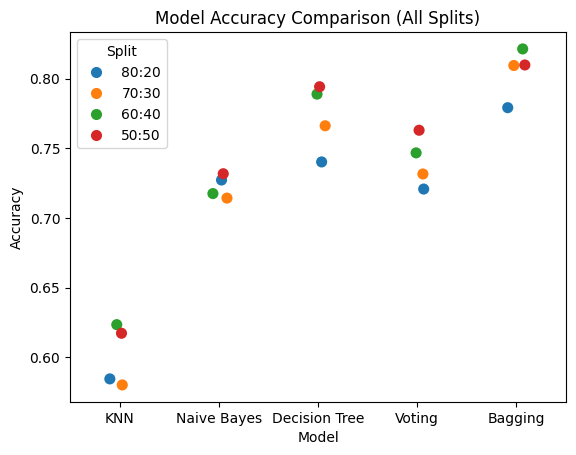

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = pd.DataFrame(all_results)

# Convert to long format
plot_df = plot_df.melt(
    id_vars='Split',
    var_name='Model',
    value_name='Accuracy'
)

sns.stripplot(
    x='Model',
    y='Accuracy',
    data=plot_df,
    hue='Split',
    size=8
)

plt.title("Model Accuracy Comparison (All Splits)")
plt.show()